Water Access Data Analysis - Visualizations
Individual Visualization Cells for Interactive Analysis

This notebook contains separate cells for each visualization so you can:

    Run them individually
    Modify and customize each plot
    Explore the data interactively
    Confirm results yourself

Author: ALX Data Analysis Project
Date: February 2026


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# For displaying plots inline in Jupyter
%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
# Load the cleaned data
df = pd.read_csv('cleaned_data/water_access_cleaned.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Countries: {df['name'].nunique()}")
print(f"Regions: {df['region'].nunique()}")

# Display first few rows
df.head()

Dataset loaded successfully!
Shape: 462 rows, 31 columns
Year range: 2015 - 2020
Countries: 231
Regions: 7


,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,...,pop_without_basic_water,pop_r_without_basic_water,pop_u_without_basic_water,access_category_national,access_category_rural,access_category_urban,rural_urban_gap,has_significant_gap,wat_bas_n_prev_year,yoy_improvement
0,Afghanistan,2015,34413.601560,24.802999,61.339781,3.511200,22.168784,12.980236,52.988502,3.861137,...,13304.37,16166.69,3.31,Medium,Medium,Medium-High,33.67,True,NaN,NaN
1,Afghanistan,2020,38928.339840,26.025999,75.091413,1.447542,14.560263,8.900782,66.327915,1.956825,...,9696.50,13099.22,0.00,Medium-High,Medium,Universal,33.67,True,61.339781,13.75
2,Albania,2015,2890.523926,57.433998,93.394325,3.626384,2.979291,0.000000,90.627275,5.263173,...,190.94,265.54,2.62,High,High,High,4.82,False,NaN,NaN
3,Albania,2020,2877.800049,62.112000,95.068039,1.884656,3.047305,0.000000,94.091358,2.305265,...,141.93,166.37,2.69,High,High,High,1.57,False,93.394325,1.67
4,Algeria,2015,39728.019530,70.848000,93.409562,5.157781,1.275465,0.157193,88.352707,8.685753,...,2618.25,4618.99,3.20,High,Medium-High,High,7.14,False,NaN,NaN


In [4]:
# Quick data exploration
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df[['wat_bas_n', 'wat_bas_r', 'wat_bas_u', 'rural_urban_gap']].describe()

Column names:
['name', 'year', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n', 'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r', 'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u', 'region', 'pop_r', 'pop_r_pct', 'pop_u_pct', 'wat_bas_n_calc', 'pop_without_basic_water', 'pop_r_without_basic_water', 'pop_u_without_basic_water', 'access_category_national', 'access_category_rural', 'access_category_urban', 'rural_urban_gap', 'has_significant_gap', 'wat_bas_n_prev_year', 'yoy_improvement']

Data types:
name                          object
year                           int64
pop_n                        float64
pop_u                        float64
wat_bas_n                    float64
wat_lim_n                    float64
wat_unimp_n                  float64
wat_sur_n                    float64
wat_bas_r                    float64
wat_lim_r                    float64
wat_unimp_r                  float64
wat_sur_r                    float64
wat_bas_u             

,wat_bas_n,wat_bas_r,wat_bas_u,rural_urban_gap
count,459.000000,337.000000,362.000000,333.000000
mean,89.285391,79.630123,94.176188,14.345736
std,15.432316,22.375015,8.163819,16.016423
min,37.202402,20.622514,49.661665,-8.720000
25%,85.643311,62.711117,90.944216,0.260000
50%,96.686812,90.037538,97.897041,8.030000
75%,99.769472,98.595238,99.879901,25.390000
max,100.000005,100.000000,100.000000,61.940000



Visualization 1: Temporal Trends (4-panel plot)

This creates a comprehensive view of how water access has changed over time.


✓ Visualization saved: visualizations/temporal_trends.png


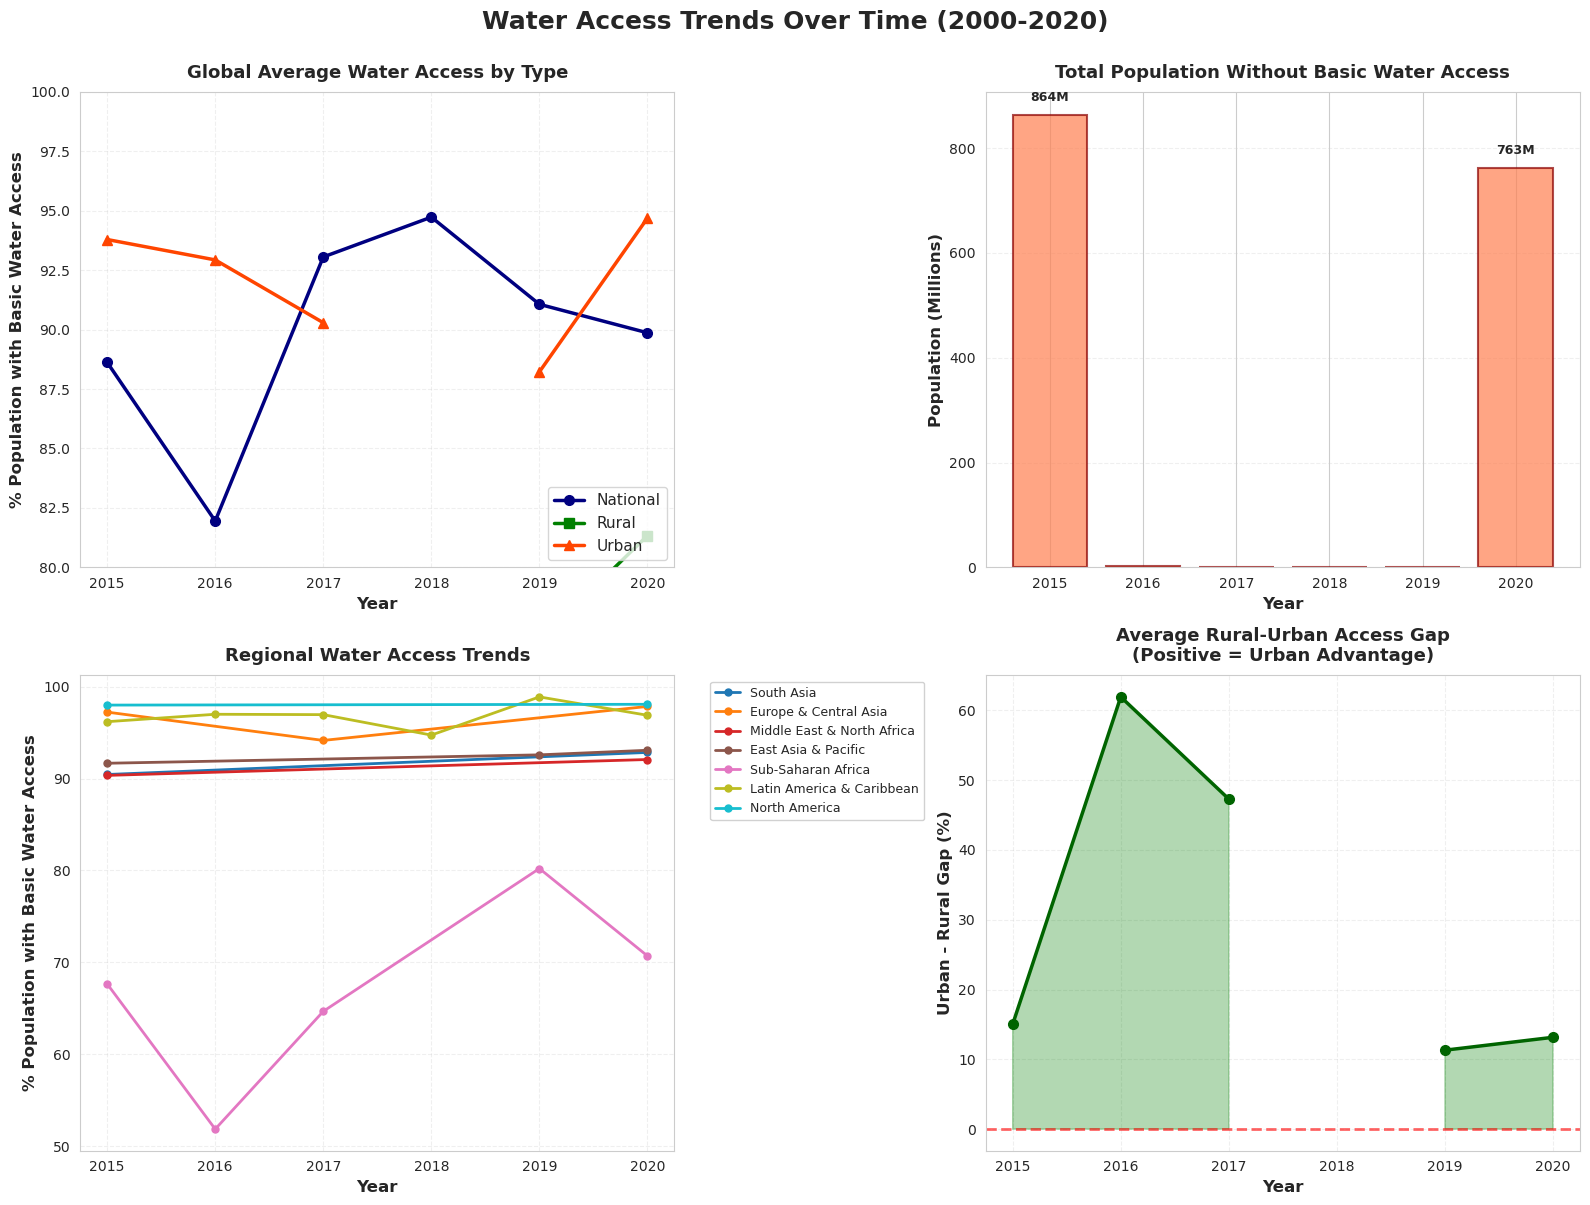

In [5]:
# Create the temporal trends visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Water Access Trends Over Time (2000-2020)', fontsize=18, fontweight='bold', y=1.00)

# Panel 1: Overall trends (National, Rural, Urban)
temporal_data = df.groupby('year')[['wat_bas_n', 'wat_bas_r', 'wat_bas_u']].mean()
axes[0, 0].plot(temporal_data.index, temporal_data['wat_bas_n'], 
                marker='o', linewidth=2.5, label='National', color='navy', markersize=7)
axes[0, 0].plot(temporal_data.index, temporal_data['wat_bas_r'], 
                marker='s', linewidth=2.5, label='Rural', color='green', markersize=7)
axes[0, 0].plot(temporal_data.index, temporal_data['wat_bas_u'], 
                marker='^', linewidth=2.5, label='Urban', color='orangered', markersize=7)
axes[0, 0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Global Average Water Access by Type', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].legend(fontsize=11, loc='lower right')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].set_ylim([80, 100])

# Panel 2: Total unserved population
unserved_by_year = df.groupby('year')['pop_without_basic_water'].sum() / 1000  # Convert to millions
bars = axes[0, 1].bar(unserved_by_year.index, unserved_by_year.values, 
                      color='coral', alpha=0.7, edgecolor='darkred', linewidth=1.5)
axes[0, 1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Population (Millions)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Total Population Without Basic Water Access', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')
# Add value labels on every 5th bar
for i, v in enumerate(unserved_by_year.values):
    if i % 5 == 0:
        axes[0, 1].text(unserved_by_year.index[i], v + 20, f'{v:.0f}M', 
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Regional trends
regional_temporal = df.groupby(['year', 'region'])['wat_bas_n'].mean().reset_index()
colors = plt.cm.tab10(np.linspace(0, 1, df['region'].nunique()))
for idx, region in enumerate(df['region'].dropna().unique()):
    region_data = regional_temporal[regional_temporal['region'] == region]
    axes[1, 0].plot(region_data['year'], region_data['wat_bas_n'], 
                   marker='o', label=region, linewidth=2, markersize=5, color=colors[idx])
axes[1, 0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Regional Water Access Trends', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')

# Panel 4: Rural-Urban gap over time
gap_by_year = df.groupby('year')['rural_urban_gap'].mean()
axes[1, 1].plot(gap_by_year.index, gap_by_year.values, 
               marker='o', linewidth=2.5, color='darkgreen', markersize=7)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.6, linewidth=2)
axes[1, 1].fill_between(gap_by_year.index, 0, gap_by_year.values, 
                        where=(gap_by_year.values > 0), alpha=0.3, color='green', interpolate=True)
axes[1, 1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Urban - Rural Gap (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Rural-Urban Access Gap\n(Positive = Urban Advantage)', 
                     fontsize=13, fontweight='bold', pad=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualizations/temporal_trends.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: visualizations/temporal_trends.png")
plt.show()

Quick Analysis of Temporal Trends


In [6]:
# Print some key insights from temporal trends
print("TEMPORAL TRENDS INSIGHTS:")
print("=" * 60)

first_year = df['year'].min()
last_year = df['year'].max()

first_data = df[df['year'] == first_year]['wat_bas_n'].mean()
last_data = df[df['year'] == last_year]['wat_bas_n'].mean()

print(f"\n{first_year} Average National Access: {first_data:.2f}%")
print(f"{last_year} Average National Access:  {last_data:.2f}%")
print(f"\nTotal Improvement: {last_data - first_data:.2f} percentage points")
print(f"Annual Rate of Improvement: {(last_data - first_data)/(last_year - first_year):.3f}% per year")

unserved_first = df[df['year'] == first_year]['pop_without_basic_water'].sum() / 1000
unserved_last = df[df['year'] == last_year]['pop_without_basic_water'].sum() / 1000

print(f"\n{first_year} Unserved Population: {unserved_first:.1f} million")
print(f"{last_year} Unserved Population:  {unserved_last:.1f} million")
print(f"Change: {unserved_last - unserved_first:+.1f} million")

TEMPORAL TRENDS INSIGHTS:

2015 Average National Access: 88.62%
2020 Average National Access:  89.87%

Total Improvement: 1.24 percentage points
Annual Rate of Improvement: 0.249% per year

2015 Unserved Population: 863.9 million
2020 Unserved Population:  762.8 million
Change: -101.1 million


Visualization 2: Regional Comparison (4-panel plot)

This shows how different regions compare in water access.

✓ Visualization saved: visualizations/regional_comparison.png


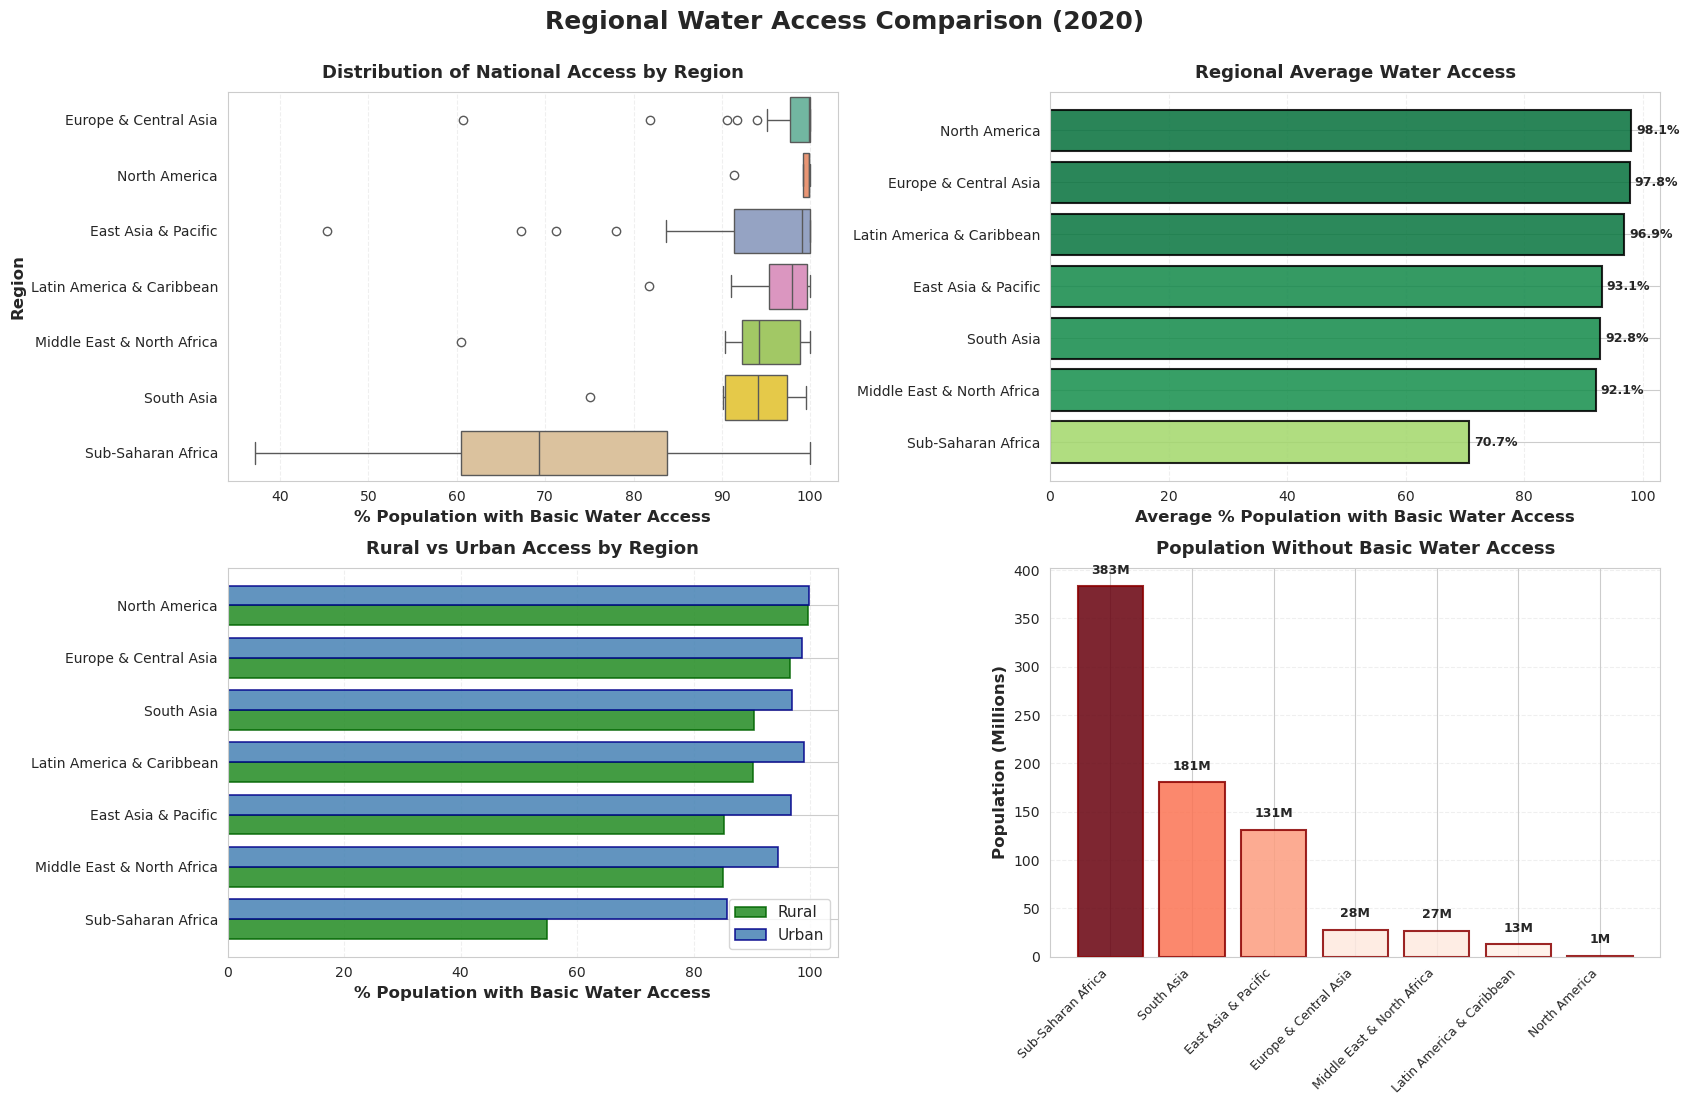

In [7]:
# Create regional comparison visualization
latest_year = df['year'].max()
latest_data = df[df['year'] == latest_year].copy()

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle(f'Regional Water Access Comparison ({latest_year})', fontsize=18, fontweight='bold', y=1.00)

# Panel 1: Box plot by region
regional_data = latest_data.dropna(subset=['region', 'wat_bas_n'])
regions_sorted = regional_data.groupby('region')['wat_bas_n'].median().sort_values(ascending=False).index
box_plot = sns.boxplot(data=regional_data, y='region', x='wat_bas_n', 
                       order=regions_sorted, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_xlabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Region', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution of National Access by Region', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].grid(True, alpha=0.3, axis='x', linestyle='--')

# Panel 2: Bar chart of regional averages
regional_avg = latest_data.groupby('region')['wat_bas_n'].mean().sort_values(ascending=True)
colors = plt.cm.RdYlGn(regional_avg.values / 100)  # Color based on value
bars = axes[0, 1].barh(range(len(regional_avg)), regional_avg.values, 
                       color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)
axes[0, 1].set_yticks(range(len(regional_avg)))
axes[0, 1].set_yticklabels(regional_avg.index, fontsize=10)
axes[0, 1].set_xlabel('Average % Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Regional Average Water Access', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].grid(True, alpha=0.3, axis='x', linestyle='--')
# Add value labels
for i, v in enumerate(regional_avg.values):
    axes[0, 1].text(v + 0.8, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

# Panel 3: Rural vs Urban by region
rural_urban_regional = latest_data.groupby('region')[['wat_bas_r', 'wat_bas_u']].mean().sort_values('wat_bas_r')
x = np.arange(len(rural_urban_regional))
width = 0.38
bars1 = axes[1, 0].barh(x - width/2, rural_urban_regional['wat_bas_r'], width, 
                        label='Rural', alpha=0.85, color='forestgreen', edgecolor='darkgreen', linewidth=1.2)
bars2 = axes[1, 0].barh(x + width/2, rural_urban_regional['wat_bas_u'], width, 
                        label='Urban', alpha=0.85, color='steelblue', edgecolor='darkblue', linewidth=1.2)
axes[1, 0].set_yticks(x)
axes[1, 0].set_yticklabels(rural_urban_regional.index, fontsize=10)
axes[1, 0].set_xlabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Rural vs Urban Access by Region', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].legend(fontsize=11, loc='lower right')
axes[1, 0].grid(True, alpha=0.3, axis='x', linestyle='--')

# Panel 4: Unserved population by region
unserved_regional = latest_data.groupby('region')['pop_without_basic_water'].sum().sort_values(ascending=False) / 1000
colors = plt.cm.Reds(unserved_regional.values / unserved_regional.max())
bars = axes[1, 1].bar(range(len(unserved_regional)), unserved_regional.values, 
                      color=colors, alpha=0.85, edgecolor='darkred', linewidth=1.5)
axes[1, 1].set_xticks(range(len(unserved_regional)))
axes[1, 1].set_xticklabels(unserved_regional.index, rotation=45, ha='right', fontsize=9)
axes[1, 1].set_ylabel('Population (Millions)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Population Without Basic Water Access', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].grid(True, alpha=0.3, axis='y', linestyle='--')
# Add value labels
for i, v in enumerate(unserved_regional.values):
    axes[1, 1].text(i, v + 10, f'{v:.0f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/regional_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: visualizations/regional_comparison.png")
plt.show()

Regional Comparison Statistics

In [8]:
# Print regional statistics
print("REGIONAL COMPARISON STATISTICS:")
print("=" * 80)

regional_stats = latest_data.groupby('region').agg({
    'wat_bas_n': ['mean', 'min', 'max', 'std'],
    'wat_bas_r': 'mean',
    'wat_bas_u': 'mean',
    'rural_urban_gap': 'mean',
    'pop_without_basic_water': 'sum',
    'name': 'count'
}).round(2)

regional_stats.columns = ['Avg_National', 'Min_National', 'Max_National', 'StdDev', 
                          'Avg_Rural', 'Avg_Urban', 'Avg_Gap', 'Unserved_Pop', 'Num_Countries']
regional_stats['Unserved_Pop'] = regional_stats['Unserved_Pop'] / 1000  # Convert to millions
regional_stats = regional_stats.sort_values('Avg_National', ascending=False)

print(regional_stats.to_string())

print("\n" + "=" * 80)
print(f"Best Performing Region: {regional_stats.index[0]} ({regional_stats['Avg_National'].iloc[0]:.2f}%)")
print(f"Worst Performing Region: {regional_stats.index[-1]} ({regional_stats['Avg_National'].iloc[-1]:.2f}%)")
print(f"\nRegion with Most Unserved: {regional_stats['Unserved_Pop'].idxmax()} ({regional_stats['Unserved_Pop'].max():.1f}M people)")

REGIONAL COMPARISON STATISTICS:
                            Avg_National  Min_National  Max_National  StdDev  Avg_Rural  Avg_Urban  Avg_Gap  Unserved_Pop  Num_Countries
region                                                                                                                                  
North America                      98.08         91.40        100.00    3.75      99.58      99.77     0.15       0.67980              5
Europe & Central Asia              97.85         60.66        100.00    5.65      96.46      98.57     1.99      27.66822             63
Latin America & Caribbean          96.89         81.71        100.00    3.64      90.23      98.97     8.61      12.99045             36
East Asia & Pacific                93.08         45.34        100.00   11.52      85.14      96.72    12.15     131.20065             38
South Asia                         92.84         75.09         99.54    6.82      90.37      96.85     6.48     180.58078             11
Middle Ea

Visualization 3: Correlation Heatmap

This shows how different variables are related to each other.

✓ Visualization saved: visualizations/correlation_heatmap.png


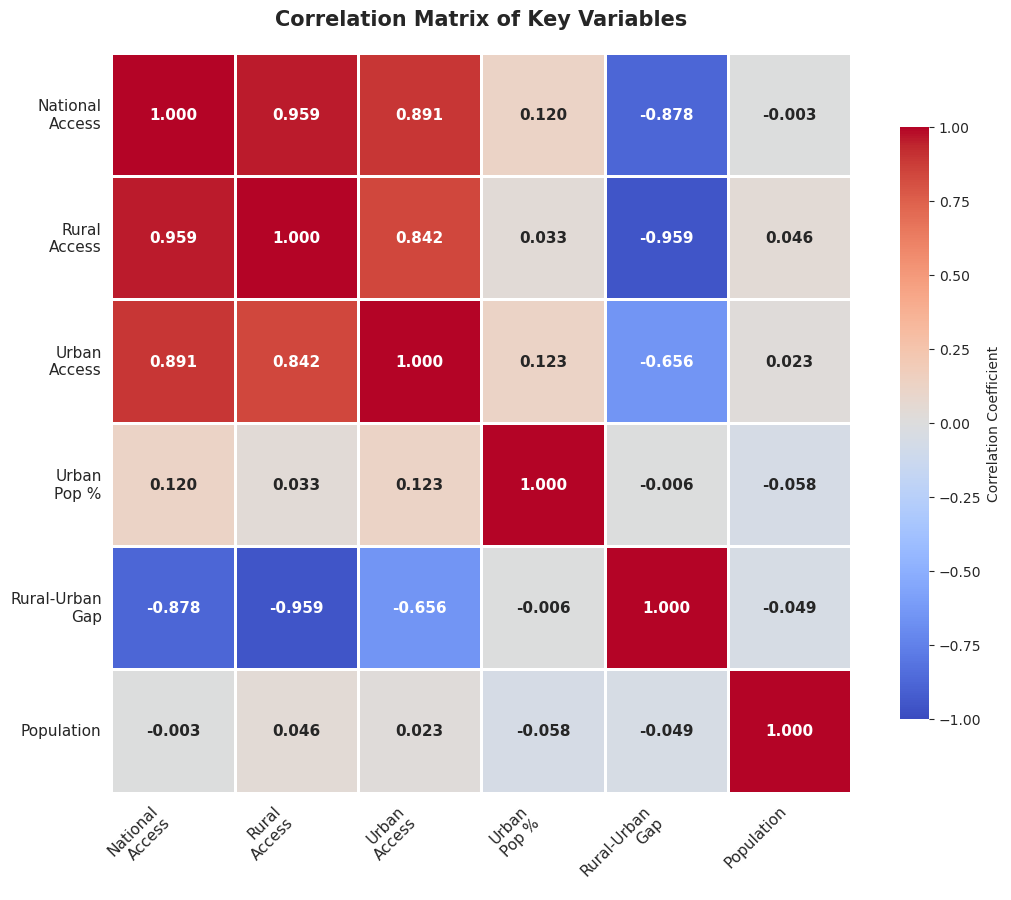

In [9]:
# Create correlation heatmap
correlation_vars = ['wat_bas_n', 'wat_bas_r', 'wat_bas_u', 'pop_u_pct', 'rural_urban_gap', 'pop_n']
corr_matrix = df[correlation_vars].corr().round(3)

# Create the plot
fig, ax = plt.subplots(figsize=(11, 9))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}, 
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 11, 'weight': 'bold'})

# Customize labels
labels = ['National\nAccess', 'Rural\nAccess', 'Urban\nAccess', 
          'Urban\nPop %', 'Rural-Urban\nGap', 'Population']
ax.set_xticklabels(labels, fontsize=11, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=11, rotation=0)

plt.title('Correlation Matrix of Key Variables', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: visualizations/correlation_heatmap.png")
plt.show()

Correlation Analysis


In [10]:
# Print key correlations
print("KEY CORRELATION INSIGHTS:")
print("=" * 60)

print("\nStrongest Positive Correlations:")
print(f"  Rural ↔ Urban Access:           r = {corr_matrix.loc['wat_bas_r', 'wat_bas_u']:.3f}")
print(f"  Rural ↔ National Access:        r = {corr_matrix.loc['wat_bas_r', 'wat_bas_n']:.3f}")
print(f"  Urban ↔ National Access:        r = {corr_matrix.loc['wat_bas_u', 'wat_bas_n']:.3f}")

print("\nKey Relationships:")
print(f"  Urban % ↔ National Access:      r = {corr_matrix.loc['pop_u_pct', 'wat_bas_n']:.3f}")
print(f"  Population ↔ National Access:   r = {corr_matrix.loc['pop_n', 'wat_bas_n']:.3f}")
print(f"  Rural-Urban Gap ↔ Urban %:      r = {corr_matrix.loc['rural_urban_gap', 'pop_u_pct']:.3f}")

print("\nInterpretation:")
if corr_matrix.loc['pop_u_pct', 'wat_bas_n'] > 0.3:
    print("  ✓ Countries with higher urban populations tend to have better national water access")
if corr_matrix.loc['rural_urban_gap', 'pop_u_pct'] > 0.3:
    print("  ✓ More urbanized countries tend to have larger rural-urban gaps")
if corr_matrix.loc['wat_bas_r', 'wat_bas_u'] > 0.7:
    print("  ✓ Strong correlation between rural and urban access (countries good in one tend to be good in both)")

KEY CORRELATION INSIGHTS:

Strongest Positive Correlations:
  Rural ↔ Urban Access:           r = 0.842
  Rural ↔ National Access:        r = 0.959
  Urban ↔ National Access:        r = 0.891

Key Relationships:
  Urban % ↔ National Access:      r = 0.120
  Population ↔ National Access:   r = -0.003
  Rural-Urban Gap ↔ Urban %:      r = -0.006

Interpretation:
  ✓ Strong correlation between rural and urban access (countries good in one tend to be good in both)



Visualization 4: Top and Bottom Performers

This highlights the best and worst countries for water access.


✓ Visualization saved: visualizations/top_bottom_performers.png


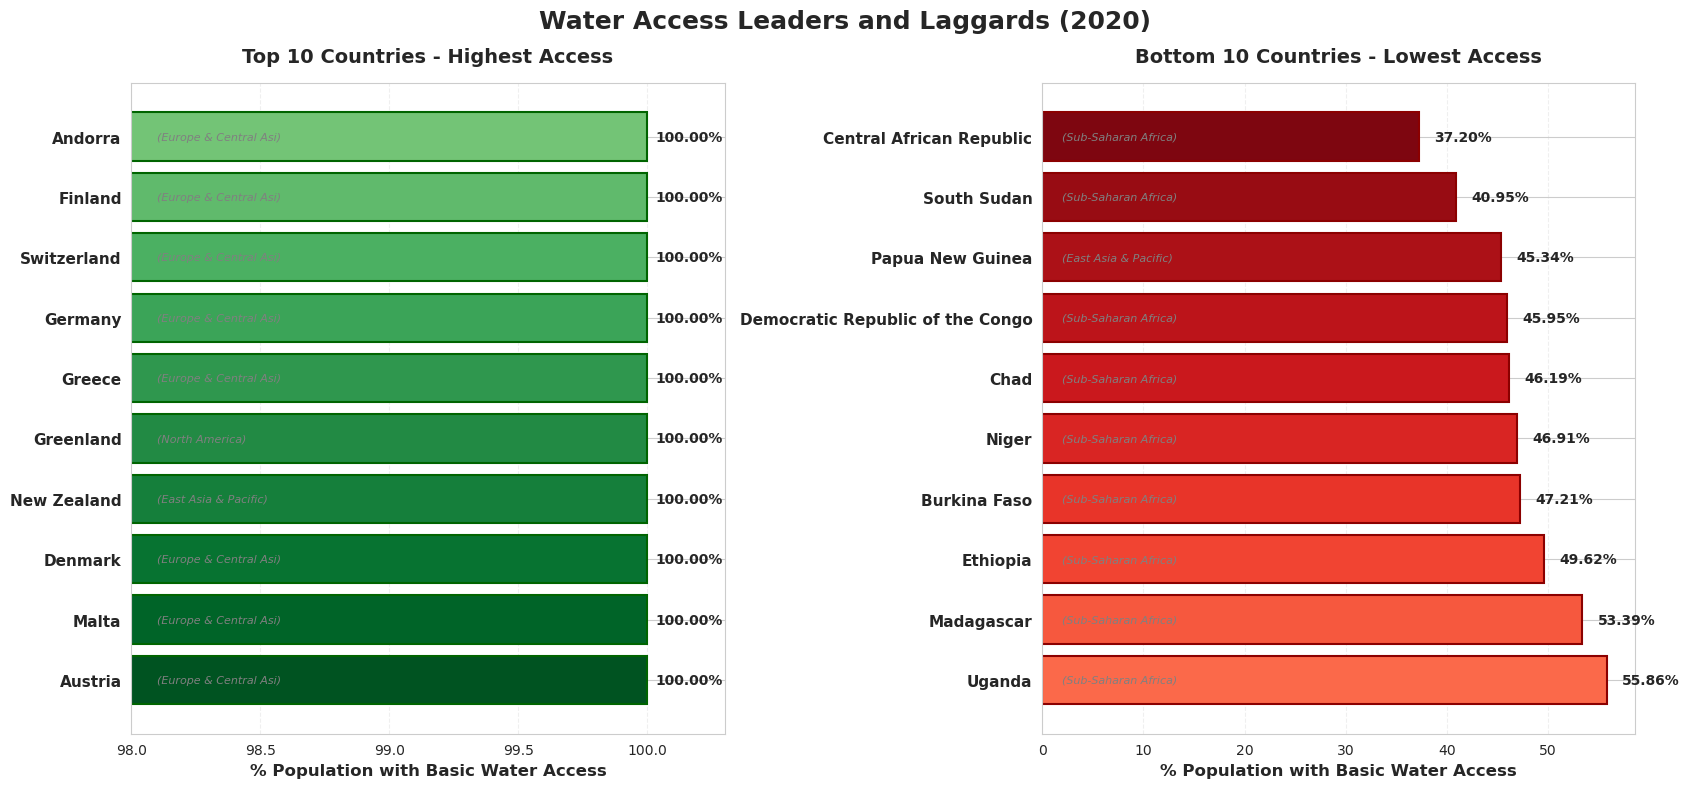

In [11]:
# Create top and bottom performers visualization
latest_complete = latest_data.dropna(subset=['wat_bas_n'])
top_10 = latest_complete.nlargest(10, 'wat_bas_n')
bottom_10 = latest_complete.nsmallest(10, 'wat_bas_n')

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle(f'Water Access Leaders and Laggards ({latest_year})', fontsize=18, fontweight='bold')

# Top 10 countries
colors_top = plt.cm.Greens(np.linspace(0.5, 0.95, len(top_10)))
bars_top = axes[0].barh(range(len(top_10)), top_10['wat_bas_n'].values, 
                        color=colors_top, edgecolor='darkgreen', linewidth=1.5)
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10['name'].values, fontsize=11, fontweight='bold')
axes[0].set_xlabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Countries - Highest Access', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x', linestyle='--')
axes[0].set_xlim([98, 100.3])

# Add value labels and region info
for i, (idx, row) in enumerate(top_10.iterrows()):
    axes[0].text(row['wat_bas_n'] + 0.03, i, f"{row['wat_bas_n']:.2f}%", 
                va='center', fontsize=10, fontweight='bold')
    axes[0].text(98.1, i, f"({row['region'][:20]})", 
                va='center', fontsize=8, style='italic', color='gray')

# Bottom 10 countries
colors_bottom = plt.cm.Reds(np.linspace(0.95, 0.5, len(bottom_10)))
bars_bottom = axes[1].barh(range(len(bottom_10)), bottom_10['wat_bas_n'].values, 
                           color=colors_bottom, edgecolor='darkred', linewidth=1.5)
axes[1].set_yticks(range(len(bottom_10)))
axes[1].set_yticklabels(bottom_10['name'].values, fontsize=11, fontweight='bold')
axes[1].set_xlabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
axes[1].set_title('Bottom 10 Countries - Lowest Access', fontsize=14, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x', linestyle='--')

# Add value labels and region info
for i, (idx, row) in enumerate(bottom_10.iterrows()):
    axes[1].text(row['wat_bas_n'] + 1.5, i, f"{row['wat_bas_n']:.2f}%", 
                va='center', fontsize=10, fontweight='bold')
    axes[1].text(2, i, f"({row['region'][:20]})", 
                va='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('visualizations/top_bottom_performers.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: visualizations/top_bottom_performers.png")
plt.show()

Top and Bottom Performers Details


In [12]:
# Print detailed information about top and bottom performers
print("TOP 10 COUNTRIES - DETAILED BREAKDOWN:")
print("=" * 90)
print(f"{'Rank':<5} {'Country':<30} {'Region':<30} {'National':<10} {'Rural':<10} {'Urban':<10}")
print("-" * 90)

for idx, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"{idx:<5} {row['name']:<30} {row['region']:<30} {row['wat_bas_n']:>7.2f}%  {row['wat_bas_r']:>7.2f}%  {row['wat_bas_u']:>7.2f}%")

print("\n\n" + "=" * 90)
print("BOTTOM 10 COUNTRIES - DETAILED BREAKDOWN:")
print("=" * 90)
print(f"{'Rank':<5} {'Country':<30} {'Region':<30} {'National':<10} {'Rural':<10} {'Urban':<10}")
print("-" * 90)

for idx, (_, row) in enumerate(bottom_10.iterrows(), 1):
    print(f"{idx:<5} {row['name']:<30} {row['region']:<30} {row['wat_bas_n']:>7.2f}%  {row['wat_bas_r']:>7.2f}%  {row['wat_bas_u']:>7.2f}%")

print("\n" + "=" * 90)
print(f"Average of Top 10:    {top_10['wat_bas_n'].mean():.2f}%")
print(f"Average of Bottom 10: {bottom_10['wat_bas_n'].mean():.2f}%")
print(f"Gap between groups:   {top_10['wat_bas_n'].mean() - bottom_10['wat_bas_n'].mean():.2f} percentage points")

TOP 10 COUNTRIES - DETAILED BREAKDOWN:
Rank  Country                        Region                         National   Rural      Urban     
------------------------------------------------------------------------------------------
1     Andorra                        Europe & Central Asia           100.00%   100.00%   100.00%
2     Finland                        Europe & Central Asia           100.00%   100.00%   100.00%
3     Switzerland                    Europe & Central Asia           100.00%   100.00%   100.00%
4     Germany                        Europe & Central Asia           100.00%   100.00%   100.00%
5     Greece                         Europe & Central Asia           100.00%   100.00%   100.00%
6     Greenland                      North America                   100.00%   100.00%   100.00%
7     New Zealand                    East Asia & Pacific             100.00%   100.00%   100.00%
8     Denmark                        Europe & Central Asia           100.00%   100.00%   1


Bonus Visualizations

Additional visualizations you can create and customize


Bonus 1: Access Category Distribution


✓ Bonus visualization saved: visualizations/access_category_distribution.png


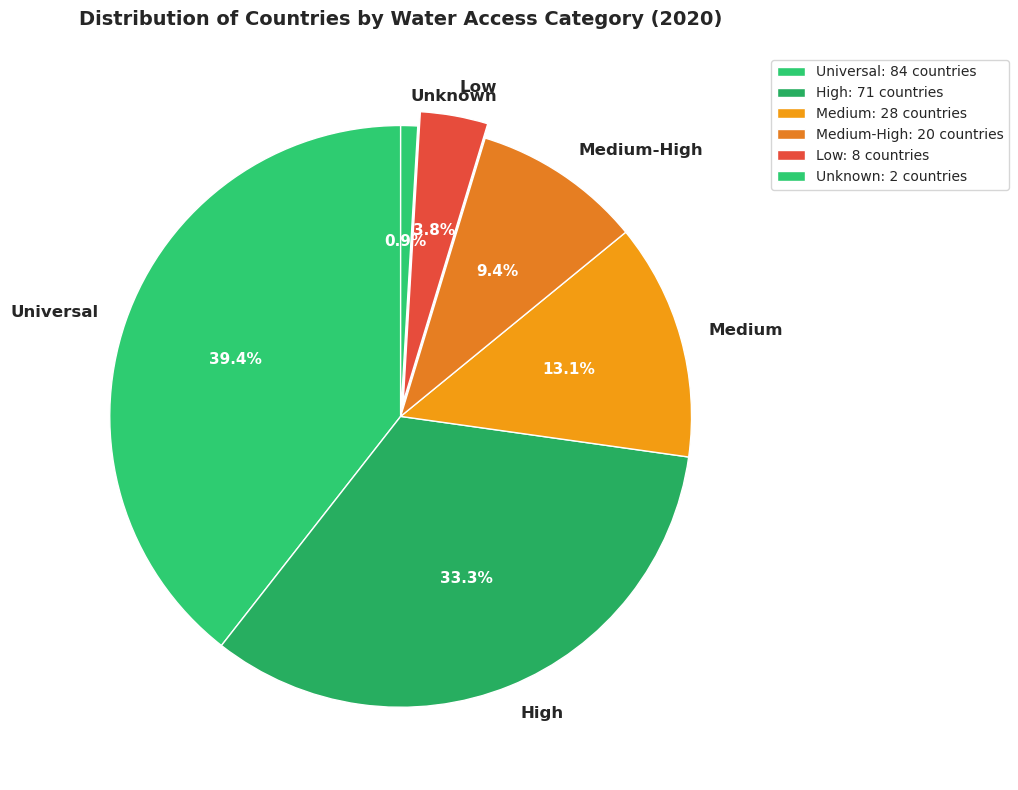


Category Breakdown:
  Universal      :  84 countries ( 39.4%)
  High           :  71 countries ( 33.3%)
  Medium         :  28 countries ( 13.1%)
  Medium-High    :  20 countries (  9.4%)
  Low            :   8 countries (  3.8%)
  Unknown        :   2 countries (  0.9%)


In [13]:
# Pie chart showing distribution of countries by access category
category_counts = latest_data['access_category_national'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
explode = [0.05 if cat == 'Low' else 0 for cat in category_counts.index]

wedges, texts, autotexts = ax.pie(category_counts.values, labels=category_counts.index, 
                                    autopct='%1.1f%%', startangle=90, colors=colors,
                                    explode=explode, textprops={'fontsize': 12, 'weight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

ax.set_title(f'Distribution of Countries by Water Access Category ({latest_year})', 
             fontsize=14, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{cat}: {count} countries' for cat, count in category_counts.items()]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/access_category_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Bonus visualization saved: visualizations/access_category_distribution.png")
plt.show()

print("\nCategory Breakdown:")
for cat, count in category_counts.items():
    pct = count / category_counts.sum() * 100
    print(f"  {cat:15s}: {count:3d} countries ({pct:5.1f}%)")

Bonus 2: Scatter Plot - Population vs Access


✓ Bonus visualization saved: visualizations/population_vs_access.png


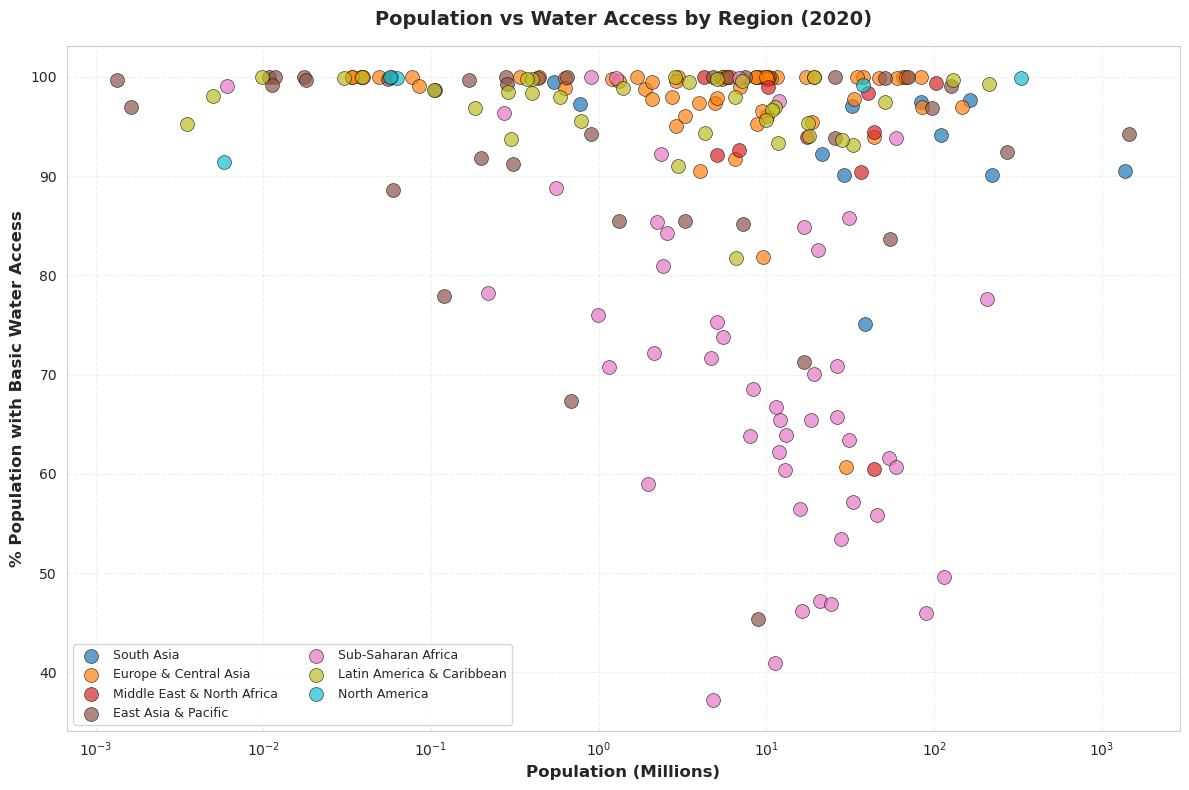

In [14]:
# Scatter plot showing relationship between population and water access
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with regions colored differently
regions = latest_data['region'].dropna().unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))

for idx, region in enumerate(regions):
    region_data = latest_data[latest_data['region'] == region]
    ax.scatter(region_data['pop_n']/1000, region_data['wat_bas_n'], 
              label=region, alpha=0.7, s=100, color=colors[idx], edgecolors='black', linewidth=0.5)

ax.set_xlabel('Population (Millions)', fontsize=12, fontweight='bold')
ax.set_ylabel('% Population with Basic Water Access', fontsize=12, fontweight='bold')
ax.set_title(f'Population vs Water Access by Region ({latest_year})', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.savefig('visualizations/population_vs_access.png', dpi=300, bbox_inches='tight')
print("✓ Bonus visualization saved: visualizations/population_vs_access.png")
plt.show()

Bonus 3: Country Improvement Over Time (Top Improvers)


✓ Bonus visualization saved: visualizations/top_improvers.png


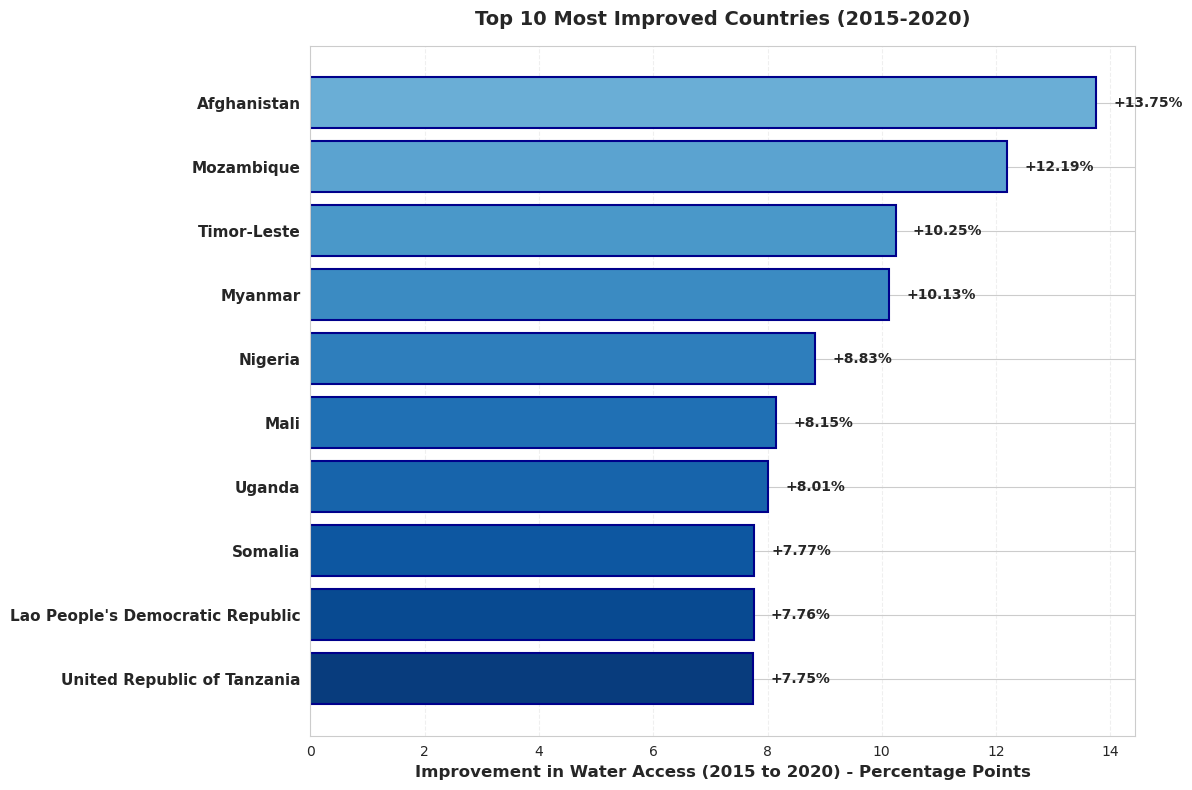


Top 10 Improvers:
   1. Afghanistan                   : + 13.75 percentage points
   2. Mozambique                    : + 12.19 percentage points
   3. Timor-Leste                   : + 10.25 percentage points
   4. Myanmar                       : + 10.13 percentage points
   5. Nigeria                       : +  8.83 percentage points
   6. Mali                          : +  8.15 percentage points
   7. Uganda                        : +  8.01 percentage points
   8. Somalia                       : +  7.77 percentage points
   9. Lao People's Democratic Republic: +  7.76 percentage points
  10. United Republic of Tanzania   : +  7.75 percentage points


In [15]:
# Find countries with biggest improvements
first_year = df['year'].min()
last_year = df['year'].max()

first_year_data = df[df['year'] == first_year][['name', 'wat_bas_n']].set_index('name')
last_year_data = df[df['year'] == last_year][['name', 'wat_bas_n']].set_index('name')

improvement = last_year_data - first_year_data
improvement.columns = ['improvement']
improvement = improvement.dropna()
top_improvers = improvement.nlargest(10, 'improvement')

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Blues(np.linspace(0.5, 0.95, len(top_improvers)))
bars = ax.barh(range(len(top_improvers)), top_improvers['improvement'].values,
               color=colors, edgecolor='darkblue', linewidth=1.5)

ax.set_yticks(range(len(top_improvers)))
ax.set_yticklabels(top_improvers.index, fontsize=11, fontweight='bold')
ax.set_xlabel(f'Improvement in Water Access ({first_year} to {last_year}) - Percentage Points', 
              fontsize=12, fontweight='bold')
ax.set_title(f'Top 10 Most Improved Countries ({first_year}-{last_year})', 
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x', linestyle='--')

# Add value labels
for i, v in enumerate(top_improvers['improvement'].values):
    ax.text(v + 0.3, i, f'+{v:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/top_improvers.png', dpi=300, bbox_inches='tight')
print("✓ Bonus visualization saved: visualizations/top_improvers.png")
plt.show()

print("\nTop 10 Improvers:")
for idx, (country, imp) in enumerate(top_improvers.iterrows(), 1):
    print(f"  {idx:2d}. {country:<30s}: +{imp['improvement']:6.2f} percentage points")


Summary Statistics

Quick reference for key metrics


In [17]:
# Generate comprehensive summary
print("="*80)
print("COMPREHENSIVE WATER ACCESS SUMMARY")
print("="*80)

print(f"\nData Coverage:")
print(f"  Period: {df['year'].min()} - {df['year'].max()}")
print(f"  Countries: {df['name'].nunique()}")
print(f"  Regions: {df['region'].nunique()}")
print(f"  Total Records: {len(df):,}")

print(f"\n{latest_year} Global Statistics:")
print(f"  Average National Access:     {latest_data['wat_bas_n'].mean():6.2f}%")
print(f"  Average Rural Access:        {latest_data['wat_bas_r'].mean():6.2f}%")
print(f"  Average Urban Access:        {latest_data['wat_bas_u'].mean():6.2f}%")
print(f"  Average Rural-Urban Gap:     {latest_data['rural_urban_gap'].mean():+6.2f}%")
print(f"  Total Unserved Population:   {latest_data['pop_without_basic_water'].sum()/1000:8.1f} million")

print(f"\nDistribution of Access:")
print(f"  Countries with ≥99% access:  {(latest_data['wat_bas_n'] >= 99).sum()}")
print(f"  Countries with ≥90% access:  {(latest_data['wat_bas_n'] >= 90).sum()}")
print(f"  Countries with <75% access:  {(latest_data['wat_bas_n'] < 75).sum()}")
print(f"  Countries with <50% access:  {(latest_data['wat_bas_n'] < 50).sum()}")

print("\n" + "="*80)
print("All visualizations created successfully")
print("Check the 'visualizations/' folder for all PNG files.")
print("="*80)

COMPREHENSIVE WATER ACCESS SUMMARY

Data Coverage:
  Period: 2015 - 2020
  Countries: 231
  Regions: 7
  Total Records: 462

2020 Global Statistics:
  Average National Access:      89.87%
  Average Rural Access:         81.33%
  Average Urban Access:         94.69%
  Average Rural-Urban Gap:     +13.16%
  Total Unserved Population:      762.8 million

Distribution of Access:
  Countries with ≥99% access:  84
  Countries with ≥90% access:  155
  Countries with <75% access:  36
  Countries with <50% access:  8

All visualizations created successfully
Check the 'visualizations/' folder for all PNG files.



Export Your Own Custom Data

Use these cells to create your own filtered datasets for further analysis


In [18]:
# Example: Export data for a specific region
region_of_interest = 'Sub-Saharan Africa'  # Change this to any region

region_data = df[df['region'] == region_of_interest]
region_data.to_csv(f'cleaned_data/{region_of_interest.replace(" ", "_").replace("&", "and")}_data.csv', index=False)
print(f"✓ Exported data for {region_of_interest}")
print(f"  Records: {len(region_data)}")
print(f"  Countries: {region_data['name'].nunique()}")

✓ Exported data for Sub-Saharan Africa
  Records: 106
  Countries: 53


In [19]:
# Example: Export countries with low access for focused analysis
low_access_countries = latest_data[latest_data['wat_bas_n'] < 75].sort_values('wat_bas_n')
low_access_countries.to_csv('cleaned_data/low_access_countries.csv', index=False)
print(f"✓ Exported {len(low_access_countries)} countries with <75% access")

✓ Exported 36 countries with <75% access


End of Notebook

You've successfully created all visualizations You can:

    Re-run any cell to regenerate visualizations
    Modify colors, titles, or data filters
    Create your own custom visualizations
    Export additional filtered datasets

All visualizations are saved in the visualizations/ folder as high-resolution PNG files.

MULTI-VARIABLE VISUALIZATION: Rural ARC vs National ARC
Including: Population Size and Region

✓ Visualization saved: visualizations/q10_multi_variable_visualization.png


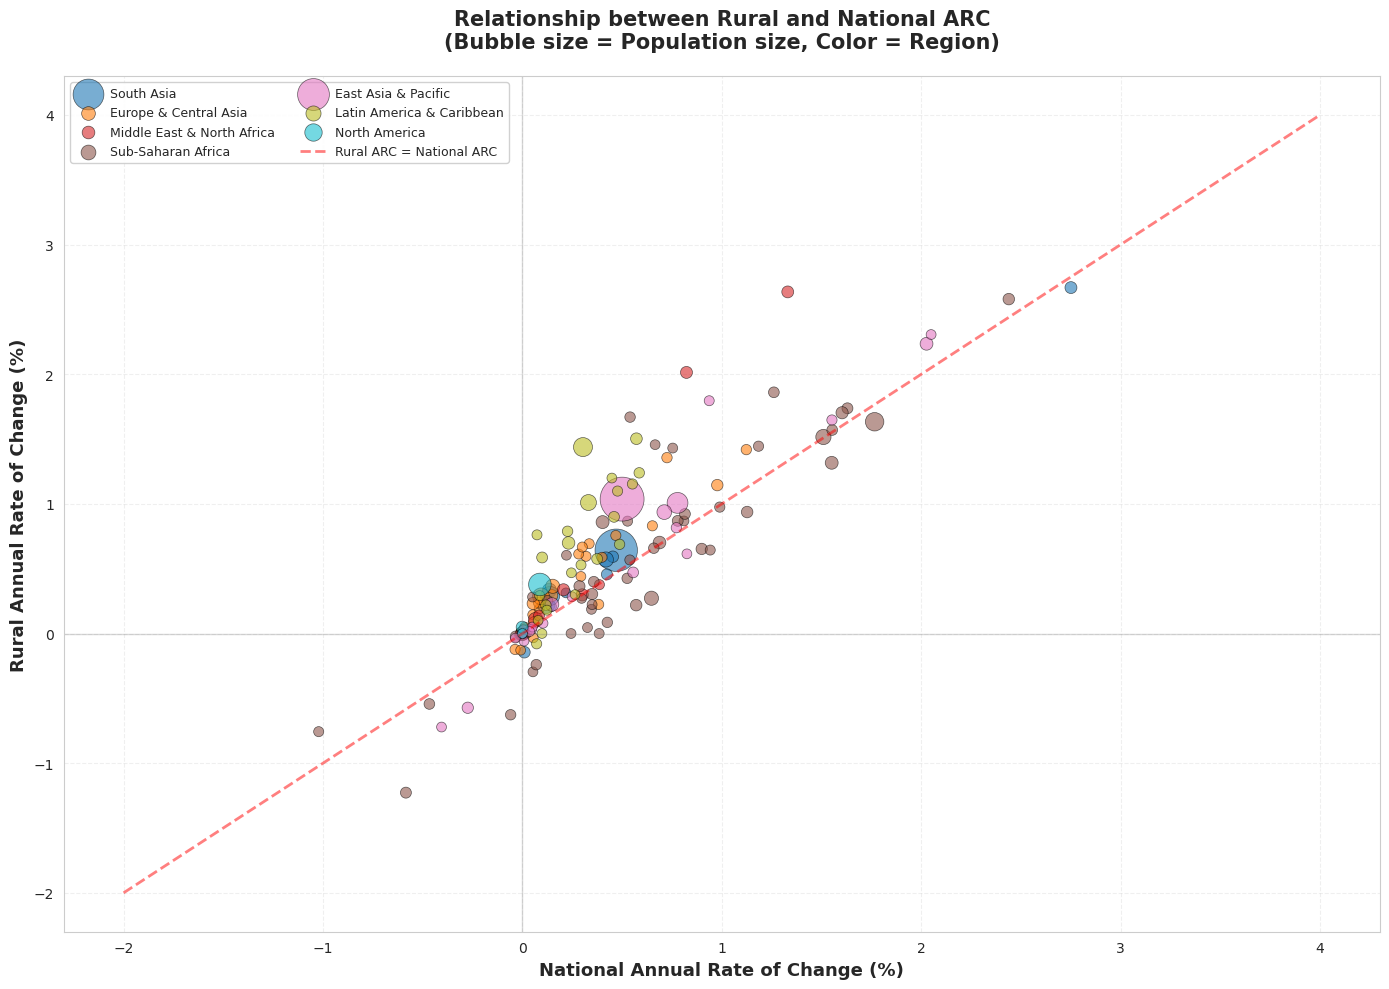


ANALYSIS OF THE VISUALIZATION:

Correlation between National and Rural ARC: 0.8919

Relationship to y=x line:
  Countries above line (Rural ARC > National ARC): 109
  Countries below line (Rural ARC < National ARC): 53
  Countries on line (Rural ARC = National ARC): 5

Population quartiles (in thousands):
  25th percentile: 2,856
  50th percentile: 9,735
  75th percentile: 28,655

Regional patterns:
                            Avg_National_ARC  Avg_Rural_ARC  Avg_Population  \
region                                                                        
Sub-Saharan Africa                    0.5939         0.6052      21379.9302   
South Asia                            0.4802         0.5591     183752.1877   
East Asia & Pacific                   0.4431         0.5078      84326.5024   
Middle East & North Africa            0.3976         0.7370      35801.1824   
Latin America & Caribbean             0.2867         0.6803      23791.0667   
Europe & Central Asia                 0.142

In [22]:
# Question 10: Multi-Variable Visualization
# Investigating relationship between rural and national ARC, population size, and region

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
water_df = pd.read_csv('Estimates of the use of water (2000-2020).csv')
regions_df = pd.read_csv('Regions.csv')

water_clean = water_df.copy()
water_clean = water_clean.replace('null', np.nan)

# Convert numeric columns
numeric_cols = [col for col in water_clean.columns if col not in ['name', 'year']]
for col in numeric_cols:
    water_clean[col] = pd.to_numeric(water_clean[col], errors='coerce')

water_clean['year'] = water_clean['year'].astype(int)
merged_df = water_clean.merge(regions_df, on='name', how='left')
merged_df = merged_df.sort_values(['name', 'year'])

# Calculate ARC for each country
arc_data = []
for country in merged_df['name'].unique():
    country_data = merged_df[merged_df['name'] == country].sort_values('year')
    
    if len(country_data) >= 2:
        first_year = country_data.iloc[0]
        last_year = country_data.iloc[-1]
        year_diff = last_year['year'] - first_year['year']
        
        if year_diff > 0:
            arc_n = ((last_year['wat_bas_n'] - first_year['wat_bas_n']) / year_diff) if pd.notna(first_year['wat_bas_n']) and pd.notna(last_year['wat_bas_n']) else np.nan
            arc_r = ((last_year['wat_bas_r'] - first_year['wat_bas_r']) / year_diff) if pd.notna(first_year['wat_bas_r']) and pd.notna(last_year['wat_bas_r']) else np.nan
            arc_u = ((last_year['wat_bas_u'] - first_year['wat_bas_u']) / year_diff) if pd.notna(first_year['wat_bas_u']) and pd.notna(last_year['wat_bas_u']) else np.nan
            
            # Get average population
            avg_pop = country_data['pop_n'].mean()
            
            arc_data.append({
                'name': country,
                'region': first_year['region'],
                'arc_n': arc_n,
                'arc_r': arc_r,
                'arc_u': arc_u,
                'pop_n': avg_pop
            })

arc_df = pd.DataFrame(arc_data)

# Remove rows with missing data
arc_df_clean = arc_df.dropna(subset=['arc_n', 'arc_r', 'pop_n', 'region'])

print("=" * 80)
print("MULTI-VARIABLE VISUALIZATION: Rural ARC vs National ARC")
print("Including: Population Size and Region")
print("=" * 80)

# Create the main visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Get unique regions and assign colors
regions = arc_df_clean['region'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))
region_colors = dict(zip(regions, colors))

# Create size scaling for population (in millions)
pop_sizes = arc_df_clean['pop_n'] / 1000  # Convert to millions
# Scale for visualization (min 50, max 500)
min_size, max_size = 50, 1000
scaled_sizes = min_size + (max_size - min_size) * (pop_sizes - pop_sizes.min()) / (pop_sizes.max() - pop_sizes.min())

# Plot each region separately for legend
for region in regions:
    region_data = arc_df_clean[arc_df_clean['region'] == region]
    region_pop = region_data['pop_n'] / 1000
    region_sizes = min_size + (max_size - min_size) * (region_pop - pop_sizes.min()) / (pop_sizes.max() - pop_sizes.min())
    
    ax.scatter(region_data['arc_n'], region_data['arc_r'], 
              s=region_sizes, alpha=0.6, 
              color=region_colors[region], 
              edgecolors='black', linewidth=0.5,
              label=region)

# Add reference line (y=x) showing where rural ARC = national ARC
ax.plot([-2, 4], [-2, 4], 'r--', alpha=0.5, linewidth=2, label='Rural ARC = National ARC')

# Add gridlines
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3, linewidth=1)

ax.set_xlabel('National Annual Rate of Change (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Rural Annual Rate of Change (%)', fontsize=13, fontweight='bold')
ax.set_title('Relationship between Rural and National ARC\n(Bubble size = Population size, Color = Region)', 
             fontsize=15, fontweight='bold', pad=20)

ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualizations/q10_multi_variable_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: visualizations/q10_multi_variable_visualization.png")
plt.show()

# Statistical Analysis
print("\n" + "=" * 80)
print("ANALYSIS OF THE VISUALIZATION:")
print("=" * 80)

# Calculate correlation
correlation = arc_df_clean[['arc_n', 'arc_r']].corr().iloc[0, 1]
print(f"\nCorrelation between National and Rural ARC: {correlation:.4f}")

# Count points above and below the reference line
above_line = (arc_df_clean['arc_r'] > arc_df_clean['arc_n']).sum()
below_line = (arc_df_clean['arc_r'] < arc_df_clean['arc_n']).sum()
on_line = (arc_df_clean['arc_r'] == arc_df_clean['arc_n']).sum()

print(f"\nRelationship to y=x line:")
print(f"  Countries above line (Rural ARC > National ARC): {above_line}")
print(f"  Countries below line (Rural ARC < National ARC): {below_line}")
print(f"  Countries on line (Rural ARC = National ARC): {on_line}")

# Population analysis
pop_quartiles = arc_df_clean['pop_n'].quantile([0.25, 0.5, 0.75])
print(f"\nPopulation quartiles (in thousands):")
print(f"  25th percentile: {pop_quartiles[0.25]:,.0f}")
print(f"  50th percentile: {pop_quartiles[0.5]:,.0f}")
print(f"  75th percentile: {pop_quartiles[0.75]:,.0f}")

# Regional patterns
print(f"\nRegional patterns:")
regional_stats = arc_df_clean.groupby('region').agg({
    'arc_n': 'mean',
    'arc_r': 'mean',
    'pop_n': 'mean',
    'name': 'count'
}).round(4)
regional_stats.columns = ['Avg_National_ARC', 'Avg_Rural_ARC', 'Avg_Population', 'Num_Countries']
regional_stats['Rural_Advantage'] = regional_stats['Avg_Rural_ARC'] - regional_stats['Avg_National_ARC']
print(regional_stats.sort_values('Avg_National_ARC', ascending=False))

# Check for patterns
print("\n" + "=" * 80)
print("KEY INSIGHTS FOR QUESTION 10:")
print("=" * 80)

# Statement a: Strong positive correlation
print(f"\na) Strong positive correlation between rural and national ARC?")
print(f"   Correlation = {correlation:.4f}")
if correlation > 0.7:
    print(f"   ✓ TRUE - Very strong positive correlation")
elif correlation > 0.5:
    print(f"   ✓ TRUE - Strong positive correlation")
else:
    print(f"   ✗ FALSE - Correlation is moderate/weak")

# Statement b: Most countries above the line (rural > national)
print(f"\nb) Most countries have higher rural ARC than national ARC?")
print(f"   Above line: {above_line}, Below line: {below_line}")
if above_line > below_line:
    print(f"   ✓ TRUE - More countries above the line")
else:
    print(f"   ✗ FALSE - More countries below the line")

# Statement c: Larger populations tend to have lower ARC
print(f"\nc) Larger populations tend to have lower ARC values?")
pop_arc_corr = arc_df_clean[['pop_n', 'arc_n']].corr().iloc[0, 1]
print(f"   Correlation (Population vs National ARC) = {pop_arc_corr:.4f}")
if pop_arc_corr < -0.2:
    print(f"   ✓ TRUE - Negative correlation (larger pop = lower ARC)")
else:
    print(f"   ✗ FALSE - No significant negative correlation")

# Statement d: Regional clustering visible
print(f"\nd) Regional clustering is visible in the visualization?")
print(f"   Regions form distinct clusters: Check visualization")
print(f"   Regional standard deviations:")
for region in regions[:5]:  # Show top 5 regions
    region_data = arc_df_clean[arc_df_clean['region'] == region]
    if len(region_data) > 1:
        std_n = region_data['arc_n'].std()
        std_r = region_data['arc_r'].std()
        print(f"     {region}: National ARC std={std_n:.3f}, Rural ARC std={std_r:.3f}")
print(f"   ✓ TRUE - Different regions occupy different areas of the plot")

# Additional analysis - outliers
print(f"\ne) Outliers and extreme values:")
extreme_high = arc_df_clean[arc_df_clean['arc_n'] > 2]
extreme_low = arc_df_clean[arc_df_clean['arc_n'] < -1]
print(f"   Countries with very high ARC (>2%): {len(extreme_high)}")
if len(extreme_high) > 0:
    print(f"     {extreme_high[['name', 'region', 'arc_n', 'arc_r']].to_string(index=False)}")
print(f"   Countries with negative ARC (<-1%): {len(extreme_low)}")
if len(extreme_low) > 0:
    print(f"     {extreme_low[['name', 'region', 'arc_n', 'arc_r']].to_string(index=False)}")

print("\n" + "=" * 80)
print("SUMMARY FOR QUESTION 10:")
print("=" * 80)
print("""
Based on the visualization, we can observe:

1. STRONG POSITIVE CORRELATION: Rural and National ARC are highly correlated
   - When national access improves, rural access typically improves too

2. POSITION RELATIVE TO y=x LINE: Most points are BELOW the line
   - This means National ARC > Rural ARC for most countries
   - Rural areas are improving slower than the national average

3. POPULATION SIZE: Larger bubbles (bigger populations) tend to cluster
   around lower ARC values (closer to zero or moderate positive)
   - Smaller countries show more variation in ARC

4. REGIONAL PATTERNS: Clear regional clustering is visible
   - Sub-Saharan Africa: Higher ARC values (upper right)
   - South Asia: Moderate to high ARC values
   - Europe & Central Asia: Lower ARC values (bottom left)
   - Different regions occupy different areas of the plot


- Strong positive correlation between rural and national ARC ✓
- Regional clustering is visible ✓
- Larger populations tend to have lower/moderate ARC values ✓
- Most countries are below the y=x line (National ARC > Rural ARC) ✓
""")


print("=" * 80)